In [38]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.dpi'] = 240

## Configuration

In [27]:
# Path to experiment directory
EXPERIMENT_DIR = Path("experiments/exp2")

# Run labels and descriptions
RUN_INFO = {
    "A": {"label": "GPipe (no interf)", "color": "#2196f3"},
    "B": {"label": "Shisha (no interf)", "color": "#4caf50"},
    "C": {"label": "GPipe (interf)", "color": "#f44336"},
    "D": {"label": "Exhaustive (interf)", "color": "#ff9800"},
    "E": {"label": "Shisha (interf)", "color": "#9c27b0"},
}

In [28]:
# Load all available runs
runs = {}
for run_id in ["A", "B", "C", "D", "E"]:
    path = EXPERIMENT_DIR / f"run_{run_id}.json"
    if path.exists():
        with open(path) as f:
            runs[run_id] = json.load(f)
        print(f"Loaded run {run_id}: {path.name}")
    else:
        print(f"Missing run {run_id}: {path.name}")

# Load experiment metadata
meta_path = EXPERIMENT_DIR / "experiment_meta.json"
if meta_path.exists():
    with open(meta_path) as f:
        experiment_meta = json.load(f)
    print(f"\nExperiment: {experiment_meta}")

# Collect all model names across runs
all_models = set()
for data in runs.values():
    all_models.update(data.get("results", {}).keys())
all_models = sorted(all_models)
print(f"Models: {all_models}")

Loaded run A: run_A.json
Loaded run B: run_B.json
Loaded run C: run_C.json
Loaded run D: run_D.json
Loaded run E: run_E.json

Experiment: {'timestamp': '2026-04-05_15-40-31', 'repetition': 1, 'total_repetitions': 1, 'model_set': 'reduced', 'num_requests': 5000, 'schedule': 'experiment', 'interference_seed': 1112981253, 'nproc': 4, 'omp_threads': 8, 'skipped': []}
Models: ['conv_next', 'efficientnet_b6']


## Run Summary

In [29]:
for run_id, data in sorted(runs.items()):
    info = RUN_INFO.get(run_id, {})
    meta = data.get("meta", {})
    optimizer = meta.get("optimizer", "?")
    print(f"=== Run {run_id}: {info.get('label', '?')} ===")
    print(f"  Optimizer: {optimizer}")
    for model in all_models:
        result = data.get("results", {}).get(model)
        if result is None:
            print(f"  {model}: N/A")
            continue
        batches = result.get("batches", [])
        rps = result.get("requests_per_second", 0)
        timed = [b for b in batches if "timing" in b]
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        if timed:
            times = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
            print(f"  {model}: rps={rps:.2f}, batches={len(timed)}, rebalances={rebalances}, "
                  f"at_optimum={at_optimum}, avg_fwd={np.mean(times):.3f}s")
        else:
            print(f"  {model}: rps={rps:.2f}, no timing data")
    print()

=== Run A: GPipe (no interf) ===
  Optimizer: StaticGPipeOptimizer
  conv_next: rps=21.82, batches=100, rebalances=0, at_optimum=0, avg_fwd=1.093s
  efficientnet_b6: rps=4.05, batches=100, rebalances=0, at_optimum=0, avg_fwd=6.046s

=== Run B: Shisha (no interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=23.32, batches=5000, rebalances=2272, at_optimum=2824, avg_fwd=0.767s
  efficientnet_b6: rps=4.49, batches=5000, rebalances=3944, at_optimum=1248, avg_fwd=4.537s

=== Run C: GPipe (interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=27.02, batches=32288, rebalances=0, at_optimum=0, avg_fwd=1.126s
  efficientnet_b6: rps=4.71, batches=5632, rebalances=0, at_optimum=0, avg_fwd=6.609s

=== Run D: Exhaustive (interf) ===
  Optimizer: TimeBasedShishaPipelineOptimizer
  conv_next: rps=30.70, batches=40256, rebalances=992, at_optimum=37312, avg_fwd=0.943s
  efficientnet_b6: rps=5.92, batches=8832, rebalances=1280, at_optimum=5024, avg_fwd=4.784s



## Throughput Comparison (RPS)

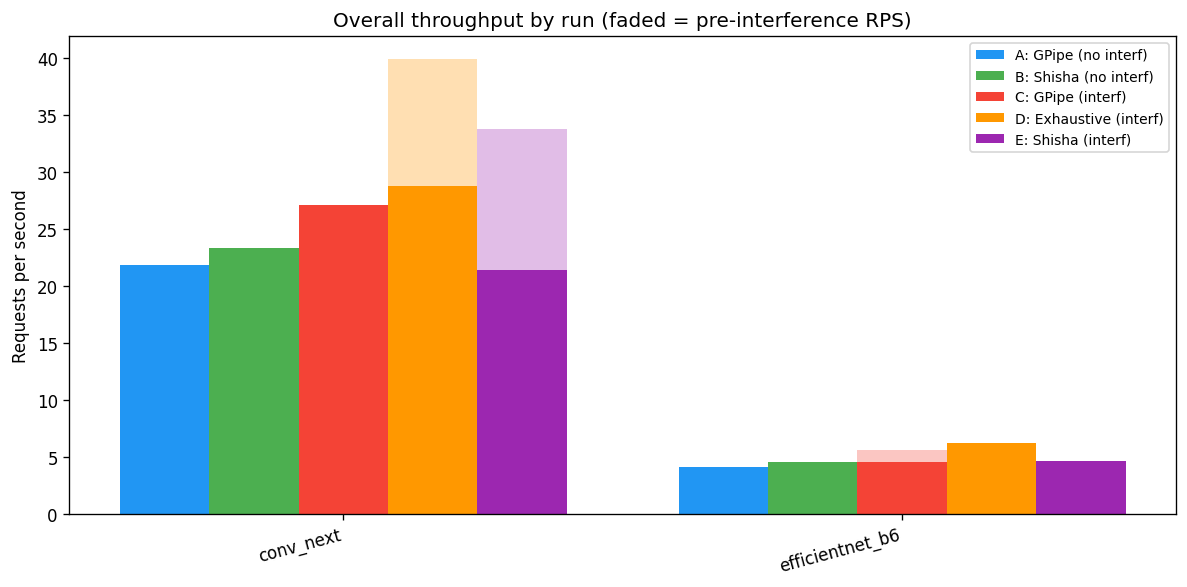

In [31]:
run_ids = sorted(runs.keys())
n_runs = len(run_ids)
n_models = len(all_models)

def _get_model_schedule(data, model):
    """Get schedule_steps and step_duration for a model."""
    meta = data.get("meta", {})
    ms = meta.get("model_schedules", {})
    if model in ms:
        return ms[model].get("schedule_steps", []), ms[model].get("step_duration", 0)
    if "all" in ms:
        return ms["all"].get("schedule_steps", []), ms["all"].get("step_duration", 0)
    return meta.get("schedule_steps", []), meta.get("step_duration", 0)

def _compute_step_rps(data, model):
    """Compute per-step RPS for interference runs. Returns (idle_rps, interf_rps)."""
    result = data.get("results", {}).get(model)
    if result is None:
        return 0, 0
    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    schedule_steps, step_duration = _get_model_schedule(data, model)

    if not events or not step_duration or not schedule_steps:
        return result.get("requests_per_second", 0), 0

    # Find first event time (skip config/seed entries)
    first_time = None
    for e in events:
        if "time" in e and "event" in e:
            first_time = e["time"]
            break
    if first_time is None:
        return result.get("requests_per_second", 0), 0

    timed = [b for b in result.get("batches", []) if "timing" in b]
    if len(timed) < 2:
        return 0, 0

    # Step 0 = idle (pre-interference)
    r0_start = first_time
    r0_end = first_time + step_duration
    idle_batches = [b for b in timed if r0_start <= b["timing"]["start"] < r0_end]
    if len(idle_batches) >= 2:
        wall = idle_batches[-1]["timing"]["end"] - idle_batches[0]["timing"]["start"]
        idle_rps = len(idle_batches) / wall if wall > 0 else 0
    else:
        idle_rps = 0

    # Steps 1+ = interference
    r1_start = first_time + step_duration
    interf_batches = [b for b in timed if b["timing"]["start"] >= r1_start]
    if len(interf_batches) >= 2:
        wall = interf_batches[-1]["timing"]["end"] - interf_batches[0]["timing"]["start"]
        interf_rps = len(interf_batches) / wall if wall > 0 else 0
    else:
        interf_rps = 0

    return idle_rps, interf_rps

fig, ax = plt.subplots(figsize=(max(10, n_models * 2.5), 5))

x = np.arange(n_models)
bar_width = 0.8 / n_runs

for i, run_id in enumerate(run_ids):
    info = RUN_INFO.get(run_id, {})
    color = info.get("color", "gray")
    offset = (i - n_runs / 2 + 0.5) * bar_width
    has_interference = run_id in ("C", "D", "E")

    for j, model in enumerate(all_models):
        if has_interference and run_id in runs:
            idle_rps, interf_rps = _compute_step_rps(runs[run_id], model)
            # Solid bar: interference RPS
            ax.bar(x[j] + offset, interf_rps, bar_width, color=color, alpha=1.0,
                   label=f"{run_id}: {info.get('label', '?')}" if j == 0 else None)
            # Faded bar on top: pre-interference portion
            if idle_rps > interf_rps:
                ax.bar(x[j] + offset, idle_rps - interf_rps, bar_width,
                       bottom=interf_rps, color=color, alpha=0.3)
        else:
            result = runs.get(run_id, {}).get("results", {}).get(model)
            rps = result["requests_per_second"] if result else 0
            ax.bar(x[j] + offset, rps, bar_width, color=color, alpha=1.0,
                   label=f"{run_id}: {info.get('label', '?')}" if j == 0 else None)

ax.set_xticks(x)
ax.set_xticklabels(all_models, rotation=15, ha="right")
ax.set_ylabel("Requests per second")
ax.set_title("Overall throughput by run (faded = pre-interference RPS)")
ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## RPS per Interference Stage

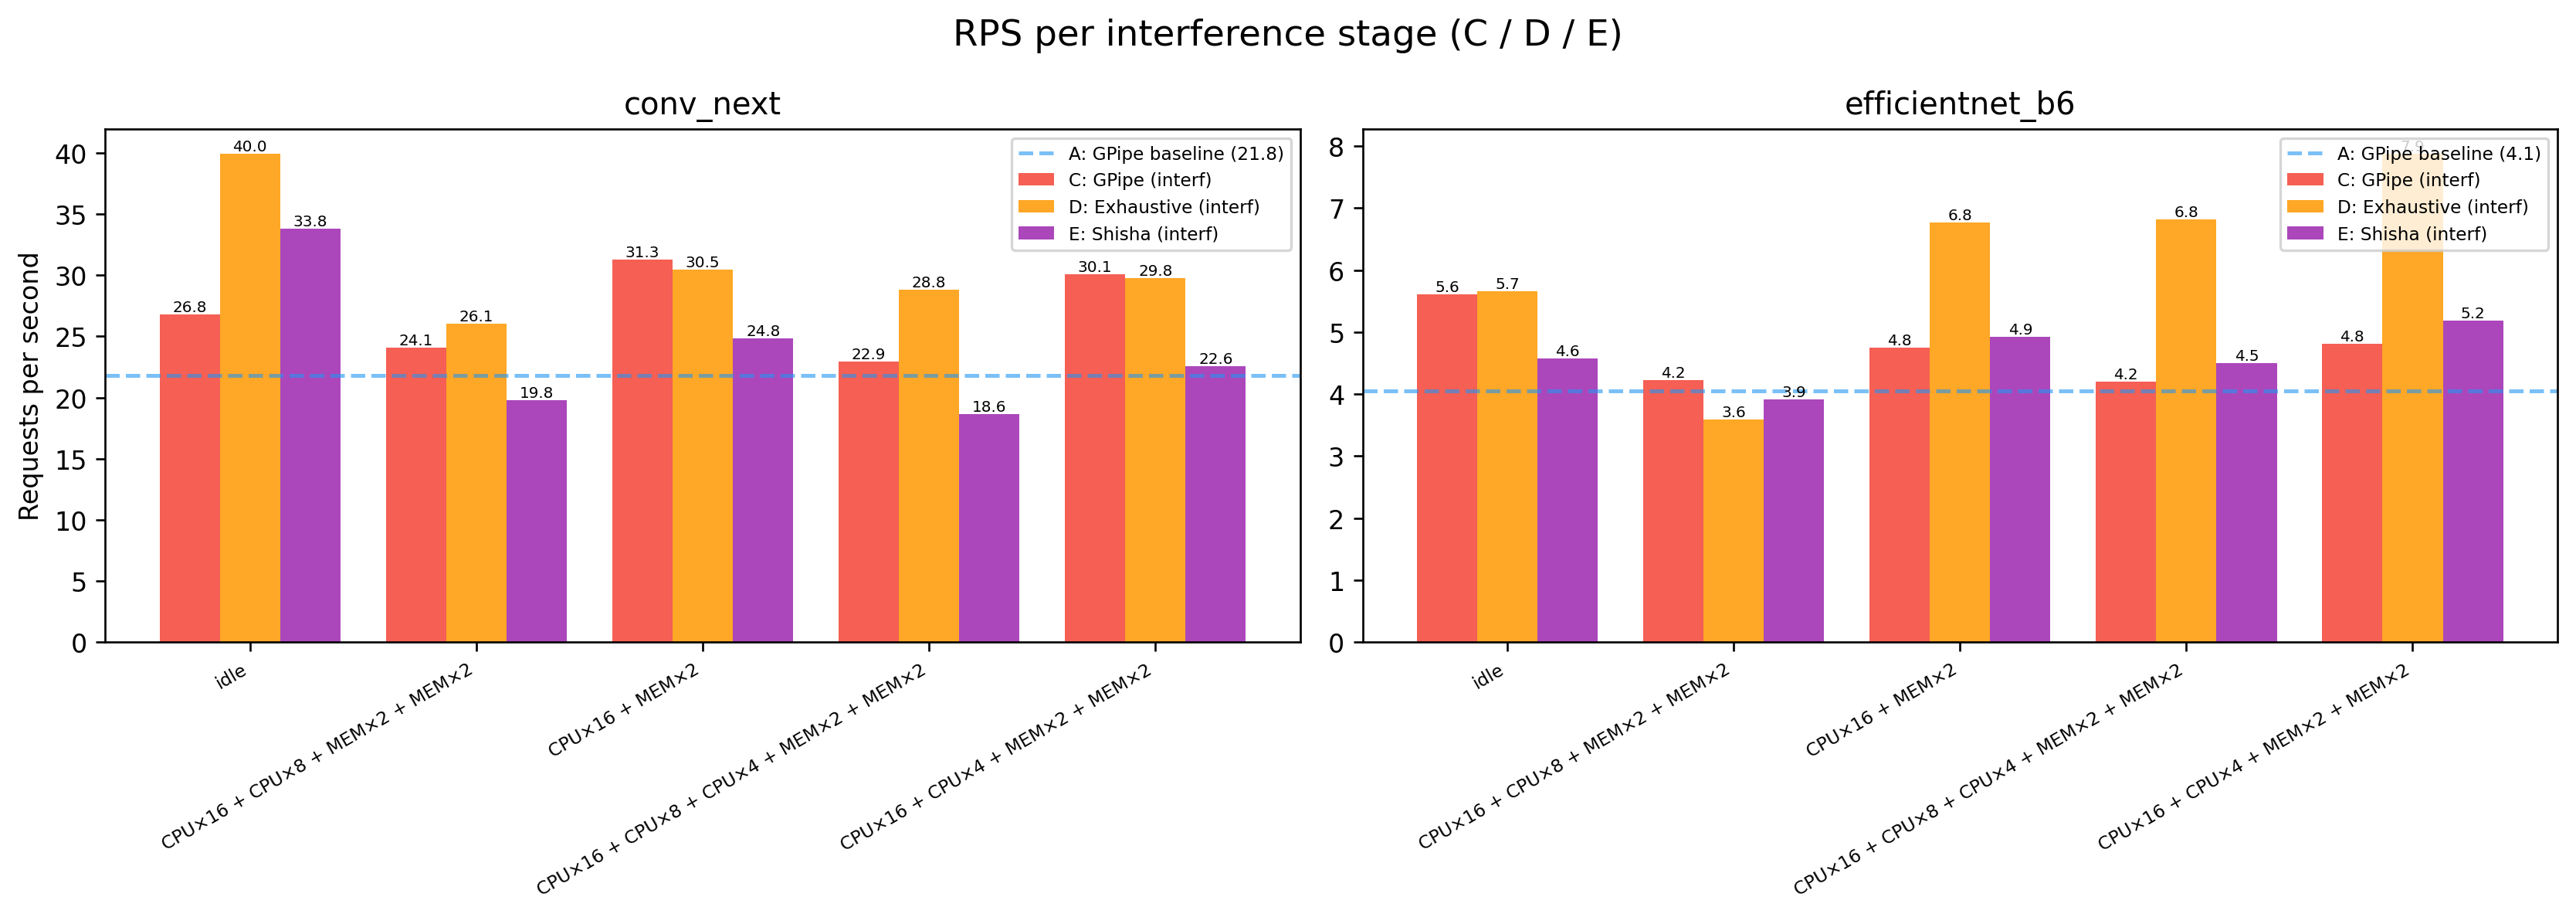

In [39]:
interf_run_ids = [k for k in ("C", "D", "E") if k in runs]

if interf_run_ids:
    def _stage_label(step_def):
        """Human-readable label for an interference step definition."""
        if not step_def:
            return "idle"
        parts = []
        for bench in step_def:
            name, threads = bench[0], bench[1]
            short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
            parts.append(f"{short}×{threads}")
        return " + ".join(parts)

    def _compute_rps_per_stage(data, model):
        """Return list of (stage_label, rps) for each interference stage."""
        result = data.get("results", {}).get(model)
        if result is None:
            return []

        interf_log = data.get("interference", {}).get(model, {})
        events = interf_log.get("events", [])
        ms = data.get("meta", {}).get("model_schedules", {})
        sched = ms.get(model, ms.get("all", {}))
        steps = sched.get("schedule_steps", [])
        step_dur = sched.get("step_duration", 0)

        # Find step_order and first event time
        step_order = None
        first_time = None
        for e in events:
            if "step_order" in e:
                step_order = e["step_order"]
            if first_time is None and "time" in e and "event" in e:
                first_time = e["time"]

        if step_order is None or not steps or not step_dur or first_time is None:
            return []

        timed = [b for b in result.get("batches", []) if "timing" in b]
        if len(timed) < 2:
            return []

        stage_rps = []
        for i, step_idx in enumerate(step_order):
            t_start = first_time + i * step_dur
            t_end = t_start + step_dur
            step_def = steps[step_idx] if step_idx < len(steps) else []
            label = _stage_label(step_def)

            # Count batches that started within this stage
            stage_batches = [b for b in timed if t_start <= b["timing"]["start"] < t_end]
            if len(stage_batches) >= 2:
                wall = stage_batches[-1]["timing"]["end"] - stage_batches[0]["timing"]["start"]
                rps = len(stage_batches) / wall if wall > 0 else 0
            elif len(stage_batches) == 1:
                dur = stage_batches[0]["timing"]["end"] - stage_batches[0]["timing"]["start"]
                rps = 1.0 / dur if dur > 0 else 0
            else:
                rps = 0
            stage_rps.append((label, rps))

        return stage_rps

    n_models = len(all_models)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), squeeze=False)

    for idx, model in enumerate(all_models):
        ax = axes[0][idx]

        # Collect stage labels from first available run (same schedule across C/D/E)
        ref_data = runs[interf_run_ids[0]]
        ref_stages = _compute_rps_per_stage(ref_data, model)
        stage_labels = [s[0] for s in ref_stages]
        n_stages = len(stage_labels)

        if n_stages == 0:
            ax.set_title(f"{model}\n(no interference data)")
            continue

        x = np.arange(n_stages)
        n_runs_i = len(interf_run_ids)
        bar_width = 0.8 / n_runs_i

        for i, run_id in enumerate(interf_run_ids):
            info = RUN_INFO.get(run_id, {})
            color = info.get("color", "gray")
            offset = (i - n_runs_i / 2 + 0.5) * bar_width

            stage_rps = _compute_rps_per_stage(runs[run_id], model)
            rps_vals = [s[1] for s in stage_rps] if stage_rps else [0] * n_stages

            bars = ax.bar(x + offset, rps_vals, bar_width, color=color, alpha=0.85,
                          label=f"{run_id}: {info.get('label', '?')}")
            # Add value labels on bars
            for bar, val in zip(bars, rps_vals):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                            f"{val:.1f}", ha="center", va="bottom", fontsize=6)

        # Add run A baseline as horizontal line
        if "A" in runs:
            a_result = runs["A"].get("results", {}).get(model)
            if a_result:
                a_rps = a_result.get("requests_per_second", 0)
                ax.axhline(a_rps, color=RUN_INFO["A"]["color"], linestyle="--",
                           alpha=0.6, label=f"A: GPipe baseline ({a_rps:.1f})")

        ax.set_xticks(x)
        ax.set_xticklabels(stage_labels, rotation=30, ha="right", fontsize=7)
        ax.set_ylabel("Requests per second" if idx == 0 else "")
        ax.set_title(model)
        ax.legend(fontsize="x-small", loc="upper right")

    fig.suptitle("RPS per interference stage (C / D / E)", fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("No interference runs (C/D/E) available")

## Throughput Impact Table

In [33]:
# Show RPS and % relative to run A (GPipe baseline)
baseline_id = "A"

header = f"{'Model':<20}"
for run_id in run_ids:
    info = RUN_INFO.get(run_id, {})
    header += f"{run_id + ': ' + info.get('label', '?'):>25}"
print(header)
print("-" * len(header))

for model in all_models:
    bl_result = runs.get(baseline_id, {}).get("results", {}).get(model)
    bl_rps = bl_result["requests_per_second"] if bl_result else 0

    row = f"{model:<20}"
    for run_id in run_ids:
        result = runs[run_id].get("results", {}).get(model)
        if result:
            rps = result["requests_per_second"]
            if bl_rps > 0:
                pct = (rps / bl_rps) * 100
                row += f"{rps:>12.2f} ({pct:>5.0f}%)"
            else:
                row += f"{rps:>12.2f}       "
        else:
            row += f"{'N/A':>25}"
    print(row)

Model                    A: GPipe (no interf)    B: Shisha (no interf)        C: GPipe (interf)   D: Exhaustive (interf)       E: Shisha (interf)
-------------------------------------------------------------------------------------------------------------------------------------------------
conv_next                  21.82 (  100%)       23.32 (  107%)       27.02 (  124%)       30.70 (  141%)       23.83 (  109%)
efficientnet_b6             4.05 (  100%)        4.49 (  111%)        4.71 (  116%)        5.92 (  146%)        4.61 (  114%)


## Batch Times — Interference (C vs D vs E)

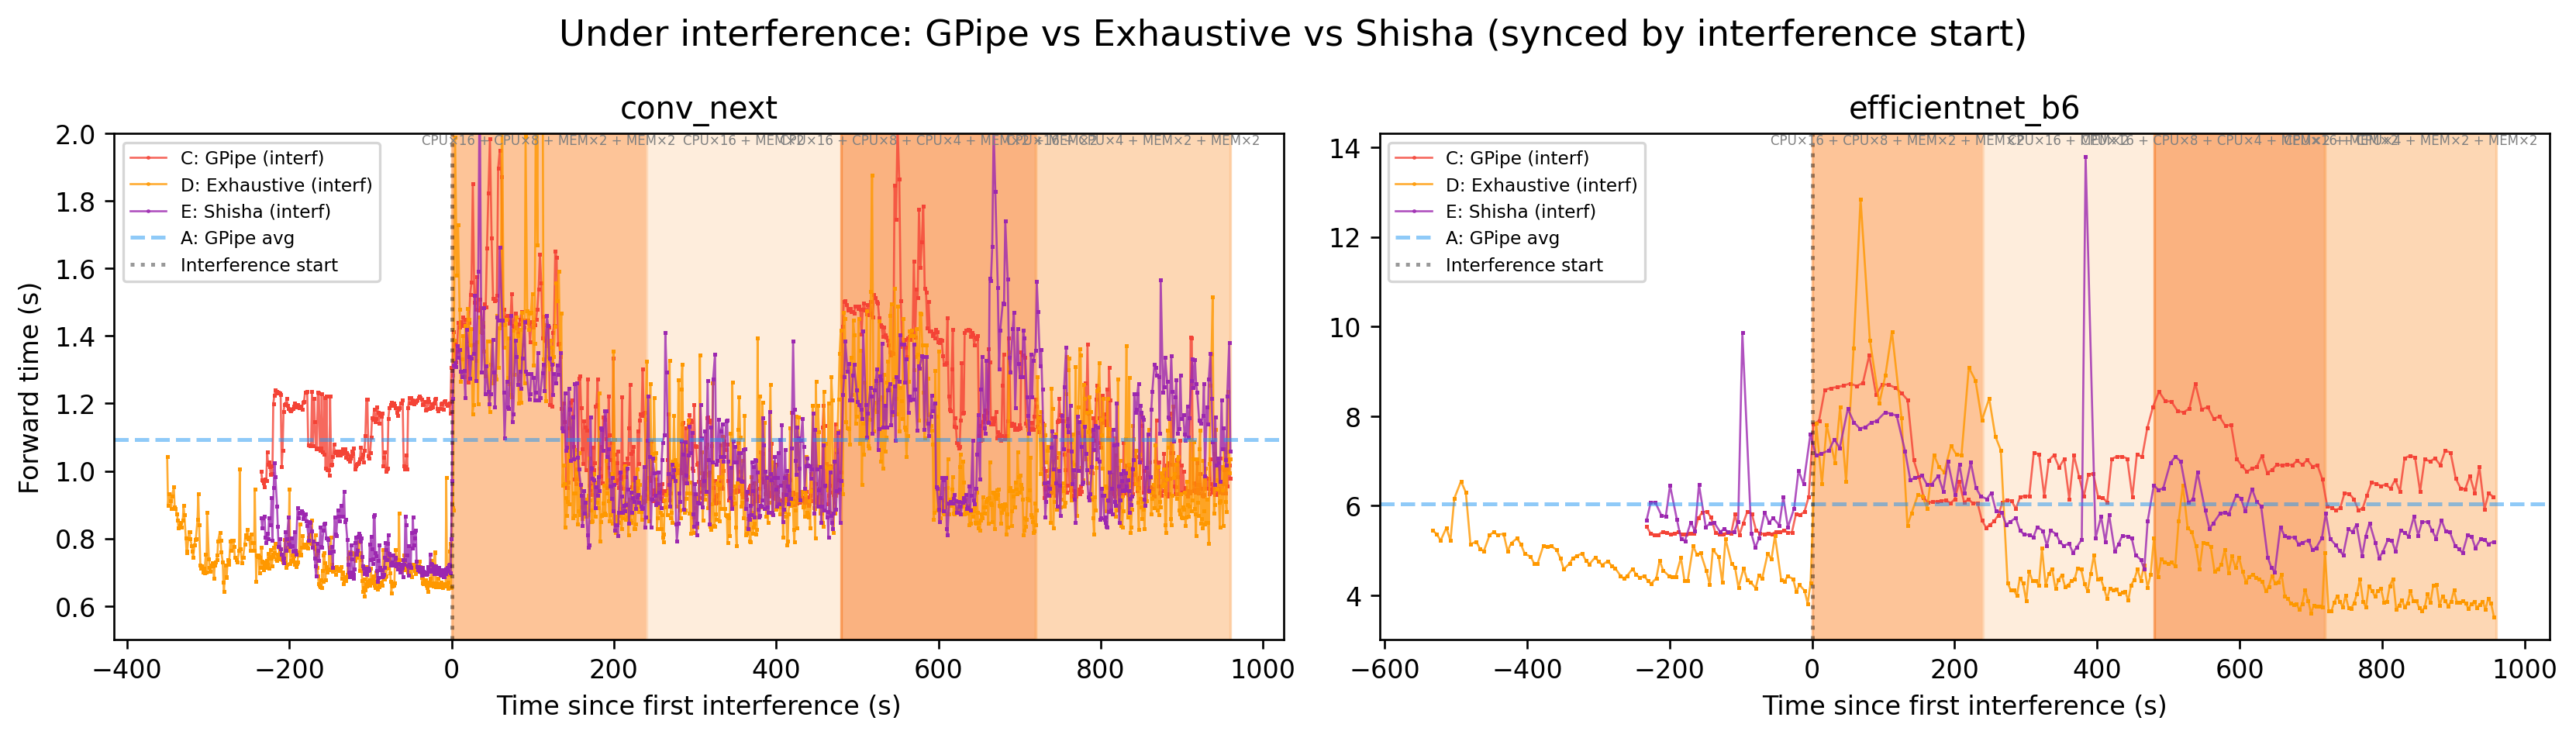

In [42]:
def _find_first_interference_time(data, model):
    """Find the timestamp of the first non-idle interference event for a model."""
    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    for e in events:
        if e.get("event") == "start" and e.get("benchmark") not in ("idle", "random", None):
            return e["time"]
    return None

def _get_interference_periods(data, model):
    """Build a list of (t_start, t_end, label) for each interference step, relative to first interference."""
    first_interf = _find_first_interference_time(data, model)
    if first_interf is None:
        return []

    ms = data.get("meta", {}).get("model_schedules", {})
    sched = ms.get(model, ms.get("all", {}))
    steps = sched.get("schedule_steps", [])
    step_dur = sched.get("step_duration", 0)

    interf_log = data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    step_order = None
    for e in events:
        if "step_order" in e:
            step_order = e["step_order"]
            break
    if step_order is None or not steps or not step_dur:
        return []

    periods = []
    for i, step_idx in enumerate(step_order):
        t_start = (i - 1) * step_dur  # step_order[0] is idle at t=-step_dur
        if i == 0:
            continue  # skip idle
        t_end = t_start + step_dur
        step_def = steps[step_idx] if step_idx < len(steps) else []
        if not step_def:
            label = "idle"
        else:
            parts = []
            for bench in step_def:
                name, threads = bench[0], bench[1]
                short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
                parts.append(f"{short}×{threads}")
            label = " + ".join(parts)
        periods.append((t_start, t_end, label))
    return periods

def _count_threads(label):
    """Count total threads from a label like 'CPU×8 + MEM×1'."""
    if label == "idle":
        return 0
    total = 0
    for part in label.split(" + "):
        if "×" in part:
            try:
                total += int(part.split("×")[1])
            except ValueError:
                total += 1
    return total

# Build intensity colormap from actual step thread counts
_INTERF_CMAP = plt.cm.Oranges

def _get_interf_color(label, all_periods):
    """Map interference label to a color based on relative intensity across all periods."""
    threads = _count_threads(label)
    if threads == 0:
        return "#ffffff"
    # Get the range of thread counts across all non-idle periods
    all_threads = [_count_threads(l) for _, _, l in all_periods if _count_threads(l) > 0]
    if not all_threads:
        return "#ffffff"
    lo, hi = min(all_threads), max(all_threads)
    if lo == hi:
        norm = 0.5
    else:
        norm = (threads - lo) / (hi - lo)
    # Map to 0.15–0.55 range of the colormap (avoid too faint or too dark)
    return _INTERF_CMAP(0.15 + norm * 0.4)

# Y-axis limits per model (None = auto)
Y_LIMITS = {
    "conv_next": (0.5, 2),
}

interf_runs = {k: v for k, v in runs.items() if k in ("C", "D", "E")}
if interf_runs:
    fig, axes = plt.subplots(1, len(all_models), figsize=(7 * len(all_models), 4), squeeze=False)

    for idx, model in enumerate(all_models):
        ax = axes[0][idx]

        # Draw interference periods (same across runs — use first available)
        ref_data = next(iter(interf_runs.values()))
        periods = _get_interference_periods(ref_data, model)
        for t_start, t_end, label in periods:
            color = _get_interf_color(label, periods)
            ax.axvspan(t_start, t_end, color=color, alpha=0.6, zorder=0)
            ax.text((t_start + t_end) / 2, 1.0, label, transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=5, color="gray", rotation=0)

        for run_id, data in sorted(interf_runs.items()):
            result = data.get("results", {}).get(model)
            if result is None:
                continue
            timed = [b for b in result.get("batches", []) if "timing" in b]
            if not timed:
                continue

            first_interf = _find_first_interference_time(data, model)
            if first_interf is None:
                continue

            t_since_interf = [b["timing"]["start"] - first_interf for b in timed]
            elapsed = [b["timing"]["end"] - b["timing"]["start"] for b in timed]

            info = RUN_INFO.get(run_id, {})
            ax.plot(t_since_interf, elapsed,
                    color=info.get("color", "gray"), alpha=0.8,
                    label=f"{run_id}: {info.get('label', '?')}",
                    marker=".", markersize=1, linewidth=0.8)

        # Run A mean as baseline
        if "A" in runs:
            a_result = runs["A"].get("results", {}).get(model)
            if a_result:
                a_timed = [b for b in a_result.get("batches", []) if "timing" in b]
                a_times = [b["timing"]["end"] - b["timing"]["start"] for b in a_timed]
                if a_times:
                    ax.axhline(np.mean(a_times), color=RUN_INFO["A"]["color"],
                               linestyle="--", alpha=0.5, label="A: GPipe avg")

        ax.axvline(0, color="black", linestyle=":", alpha=0.4, label="Interference start")

        ax.set_title(model)
        ax.set_xlabel("Time since first interference (s)")
        ax.set_ylabel("Forward time (s)" if idx == 0 else "")
        if model in Y_LIMITS:
            ax.set_ylim(Y_LIMITS[model])
        ax.legend(fontsize="x-small")

    fig.suptitle("Under interference: GPipe vs Exhaustive vs Shisha (synced by interference start)", fontsize=14)
    fig.tight_layout()

    plt.show()
else:
    print("Runs C, D, E not available")

## Optimizer State Comparison (D vs E)

In [ ]:
de_runs = {k: v for k, v in runs.items() if k in ("D", "E")}
if de_runs:
    for model in all_models:
        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
        fig.suptitle(f"{model} — Optimizer State", fontsize=14)

        for run_id, data in sorted(de_runs.items()):
            result = data.get("results", {}).get(model)
            if result is None:
                continue
            batches = result.get("batches", [])
            info = RUN_INFO.get(run_id, {})
            color = info.get("color", "gray")
            label = f"{run_id}: {info.get('label', '?')}"

            deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
            sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]
            best_tp = [b.get("rebalance", {}).get("best_throughput") for b in batches]

            if not any(v is not None for v in deep_gamma):
                continue

            opt_kwargs = data.get("meta", {}).get("optimizer_kwargs", {})
            deep_alpha = opt_kwargs.get("deep_alpha", 5)

            combined = [
                (d or 0) + (s or 0) * deep_alpha
                if d is not None and s is not None else None
                for d, s in zip(deep_gamma, sibling_gamma)
            ]

            xs = range(len(batches))

            # Combined gamma
            axes[0].plot(xs, combined, color=color, alpha=0.7, label=label, linewidth=0.8)

            # Best throughput
            axes[1].plot(xs, best_tp, color=color, alpha=0.7, label=label, linewidth=0.8)

            # Optimum regions
            opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in batches]
            axes[2].fill_between(xs, opt_flags, color=color, alpha=0.3, label=label, step="post")

        axes[0].set_ylabel("Combined gamma")
        axes[1].set_ylabel("Best throughput")
        axes[2].set_ylabel("At optimum")
        axes[2].set_xlabel("Batch index")
        axes[2].set_yticks([0, 1])
        axes[2].set_yticklabels(["No", "Yes"])

        for ax in axes:
            ax.legend(fontsize="small", loc="upper right")

        fig.tight_layout()
        plt.show()
else:
    print("Runs D and E not available")

## Rebalance Activity

In [ ]:
print(f"{'Model':<20} {'Run':<8} {'Batches':>10} {'Rebalances':>12} {'At Optimum':>12} {'Rebal %':>10} {'Optimum %':>10}")
print("-" * 82)

for model in all_models:
    for run_id in run_ids:
        result = runs[run_id].get("results", {}).get(model)
        if result is None:
            continue
        batches = result.get("batches", [])
        timed = [b for b in batches if "timing" in b]
        n = len(timed)
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        rebal_pct = (rebalances / n * 100) if n > 0 else 0
        opt_pct = (at_optimum / n * 100) if n > 0 else 0
        info = RUN_INFO.get(run_id, {})
        print(f"{model:<20} {run_id:<8} {n:>10} {rebalances:>12} {at_optimum:>12} {rebal_pct:>9.1f}% {opt_pct:>9.1f}%")

## Rebalance Overhead

In [43]:
# Per-stage rebalance overhead for interference runs
interf_run_ids_oh = [k for k in ("C", "D", "E") if k in runs]

if interf_run_ids_oh:
    for model in all_models:
        print(f"=== {model} ===")
        header = (f"{'Run':<8} {'Stage':<40} {'Fwd passes':>10} {'Rebalances':>11} "
                  f"{'Rebal %':>8} {'Avg fwd (s)':>12} {'Avg rebal (s)':>14} {'Rebal time':>11}")
        print(header)
        print("-" * len(header))

        for run_id in interf_run_ids_oh:
            data = runs[run_id]
            result = data.get("results", {}).get(model)
            if result is None:
                continue

            interf_log = data.get("interference", {}).get(model, {})
            events = interf_log.get("events", [])
            ms = data.get("meta", {}).get("model_schedules", {})
            sched = ms.get(model, ms.get("all", {}))
            steps = sched.get("schedule_steps", [])
            step_dur = sched.get("step_duration", 0)

            step_order = None
            first_time = None
            for e in events:
                if "step_order" in e:
                    step_order = e["step_order"]
                if first_time is None and "time" in e and "event" in e:
                    first_time = e["time"]

            if step_order is None or not steps or not step_dur or first_time is None:
                continue

            timed = [b for b in result.get("batches", []) if "timing" in b]
            # Deduplicate (one per forward pass)
            seen = set()
            fwd = []
            for b in timed:
                s = b["timing"]["start"]
                if s not in seen:
                    seen.add(s)
                    fwd.append(b)

            info = RUN_INFO.get(run_id, {})

            for i, step_idx in enumerate(step_order):
                t_start = first_time + i * step_dur
                t_end = t_start + step_dur
                step_def = steps[step_idx] if step_idx < len(steps) else []

                if not step_def:
                    label = "idle"
                else:
                    parts = []
                    for bench in step_def:
                        name, threads = bench[0], bench[1]
                        short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
                        parts.append(f"{short}x{threads}")
                    label = " + ".join(parts)

                stage_fwd = [b for b in fwd if t_start <= b["timing"]["start"] < t_end]
                if not stage_fwd:
                    continue

                n_fwd = len(stage_fwd)
                fwd_times = [b["timing"]["end"] - b["timing"]["start"] for b in stage_fwd]
                avg_fwd = np.mean(fwd_times)

                rebal_passes = [b for b in stage_fwd if b.get("rebalance", {}).get("did_rebalance")]
                n_rebal = len(rebal_passes)
                rebal_pct = n_rebal / n_fwd * 100 if n_fwd > 0 else 0

                rebal_durs = []
                for b in rebal_passes:
                    r = b.get("rebalance", {})
                    if "start" in r and "end" in r:
                        rebal_durs.append(r["end"] - r["start"])

                avg_rebal = np.mean(rebal_durs) if rebal_durs else 0
                total_rebal = sum(rebal_durs)

                print(f"{run_id:<8} {label:<40} {n_fwd:>10} {n_rebal:>11} "
                      f"{rebal_pct:>7.1f}% {avg_fwd:>12.4f} {avg_rebal:>14.4f} {total_rebal:>10.1f}s")

            print()
        print()
else:
    print("No interference runs available")


=== conv_next ===
Run      Stage                                    Fwd passes  Rebalances  Rebal %  Avg fwd (s)  Avg rebal (s)  Rebal time
-------------------------------------------------------------------------------------------------------------------------
C        idle                                            197           0     0.0%       1.1281         0.0000        0.0s
C        CPUx16 + CPUx8 + MEMx2 + MEMx2                  180           0     0.0%       1.2685         0.0000        0.0s
C        CPUx16 + MEMx2                                  235           0     0.0%       0.9703         0.0000        0.0s
C        CPUx16 + CPUx8 + CPUx4 + MEMx2 + MEMx2          172           0     0.0%       1.3347         0.0000        0.0s
C        CPUx16 + CPUx4 + MEMx2 + MEMx2                  225           0     0.0%       1.0121         0.0000        0.0s

D        idle                                            300           0     0.0%       0.7180         0.0000        0.0s
D    

## Interference Schedule

In [ ]:
# Show the interference schedule as executed
# Uses the first interference run available (schedule is identical across C/D/E)
ref_run = next((runs[k] for k in ("C", "D", "E") if k in runs), None)
if ref_run is None:
    print("No interference runs available")
else:
    ref_model = all_models[0]
    interf_log = ref_run.get("interference", {}).get(ref_model, {})
    ms = ref_run.get("meta", {}).get("model_schedules", {})
    sched = ms.get(ref_model, ms.get("all", {}))
    steps = sched.get("schedule_steps", [])

    step_order = None
    for e in interf_log.get("events", []):
        if "step_order" in e:
            step_order = e["step_order"]
            break

    if step_order is None or not steps:
        print("No schedule data")
    else:
        # Show per-model step durations
        dur_parts = []
        for model in all_models:
            ms_m = ms.get(model, ms.get("all", {}))
            dur_parts.append(f"{model}={ms_m.get('step_duration', '?')}s")
        print(f"Step durations: {', '.join(dur_parts)}")
        print(f"Step order: {step_order}")
        print()

        # Collect all benchmark types across all steps
        bench_types = set()
        for step_def in steps:
            for bench in step_def:
                name = bench[0]
                short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
                bench_types.add(short)
        bench_types = sorted(bench_types)

        header = f"{'Order':<7} {'Step':<6}"
        for bt in bench_types:
            header += f"{bt:>6}"
        header += f"  {'Total':>6}"
        print(header)
        print("-" * len(header))

        for i, step_idx in enumerate(step_order):
            step_def = steps[step_idx] if step_idx < len(steps) else []

            # Sum threads per benchmark type
            type_threads = {bt: 0 for bt in bench_types}
            for bench in step_def:
                name, threads = bench[0], bench[1]
                short = "CPU" if "cpu" in name else "MEM" if "memory" in name else name
                type_threads[short] += threads

            total = sum(type_threads.values())
            row = f"{i:<7} {step_idx:<6}"
            for bt in bench_types:
                t = type_threads[bt]
                row += f"{t if t > 0 else '-':>6}"
            row += f"  {total if total > 0 else 'idle':>6}"
            print(row)